某城市月度用电量预测

某城市统计了近两年的月度居民用电量（单位：万 kWh），希望建立时间序列模型预测未来 6 个月的用电量，为电力调度提供参考。

已知历史数据如下：

| 指标 | 2025-01 | 2025-02 | 2025-03 | 2025-04 | 2025-05 | 2025-06 | 2025-07 | 2025-08 | 2025-09 | 2025-10 | 2025-11 | 2025-12 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 用电量(万kWh) | 545 | 560 | 580 | 600 | 630 | 660 | 690 | 700 | 670 | 640 | 610 | 590 |

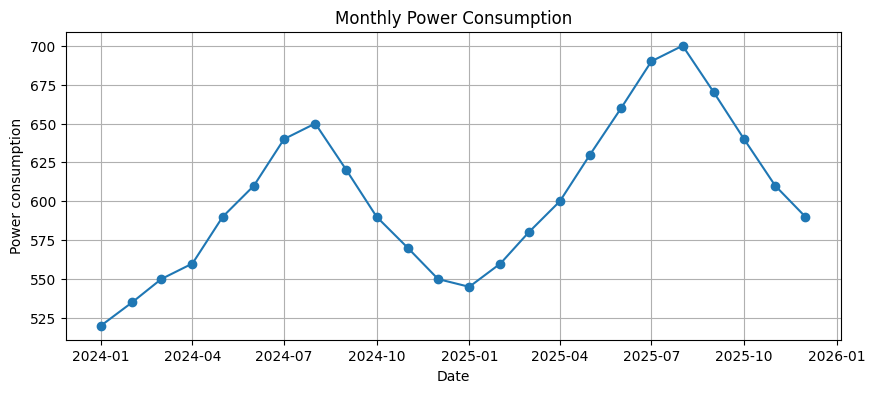

In [22]:
import pandas as pd
import matplotlib.pyplot as plt


date = [
    "2024-01","2024-02","2024-03","2024-04",
    "2024-05","2024-06","2024-07","2024-08",
    "2024-09","2024-10","2024-11","2024-12",
    "2025-01","2025-02","2025-03","2025-04",
    "2025-05","2025-06","2025-07","2025-08",
    "2025-09","2025-10","2025-11","2025-12"
]

y = [
    520,535,550,560,
    590,610,640,650,
    620,590,570,550,
    545,560,580,600,
    630,660,690,700,
    670,640,610,590
]


# 时间序列
ts = pd.Series(
    y,
    index=pd.to_datetime(date)
)


# 可视化
plt.figure(figsize=(10,4))

plt.plot(
    ts.index,
    ts.values,
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Power consumption")
plt.title("Monthly Power Consumption")

plt.grid()
plt.show()

In [23]:
from pmdarima import auto_arima
import pandas as pd
y=pd.Series(
        y,
        index=pd.date_range(
            start="2024-01",
            periods=len(y),
            freq="M"
        )
    )
model = auto_arima(
    y=y,
    seasonal=True,
    m=3
)
print(model)

C:\Users\cxh20\AppData\Local\Temp\ipykernel_41656\1272697071.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index=pd.date_range(


 ARIMA(2,0,0)(0,0,0)[3] intercept


C:\Users\cxh20\AppData\Local\Temp\ipykernel_41656\2021858294.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_index = pd.date_range(


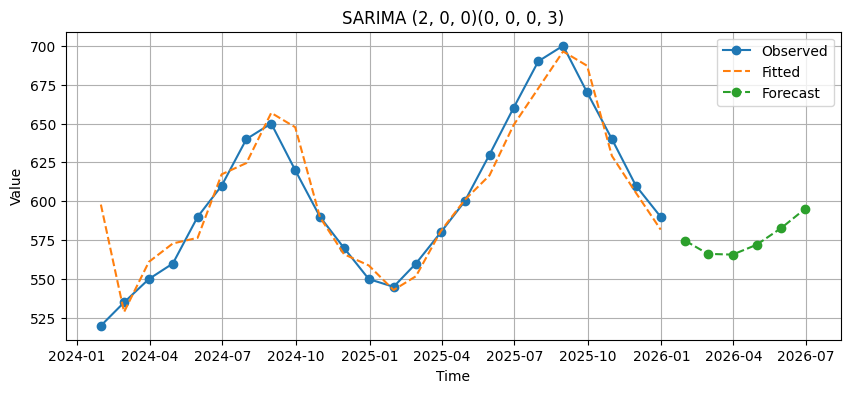

In [24]:
import matplotlib.pyplot as plt
import pandas as pd


# 历史拟合值
fitted = model.predict_in_sample()

fitted = pd.Series(
    fitted,
    index=y.index
)


# 未来预测
n_periods = 6

forecast = model.predict(
    n_periods=n_periods
)


future_index = pd.date_range(
    start=y.index[-1],
    periods=n_periods+1,
    freq="M"
)[1:]


forecast = pd.Series(
    forecast,
    index=future_index
)


# =====================
# 可视化
# =====================

plt.figure(figsize=(10,4))


# 原始数据
plt.plot(
    y.index,
    y.values,
    marker="o",
    label="Observed"
)


# 历史拟合
plt.plot(
    fitted.index,
    fitted.values,
    linestyle="--",
    label="Fitted"
)


# 未来预测
plt.plot(
    forecast.index,
    forecast.values,
    marker="o",
    linestyle="--",
    label="Forecast"
)


plt.xlabel("Time")
plt.ylabel("Value")

plt.title(
    f"SARIMA {model.order}{model.seasonal_order}"
)

plt.legend()
plt.grid()

plt.show()